In [ ]:
import os
from collections import Counter

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam

import wandb
from wandb.integration.keras import WandbCallback,  WandbMetricsLogger


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np


def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(5)

# 1. Load the CIFAR-10 datasetLoad it as we did with the Fashion MNIST and MNIST datasets in the lesson notebooks. Create visualizations of some sample images and their corresponding labels.

```
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/tmp/ipython-input-4182966102.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


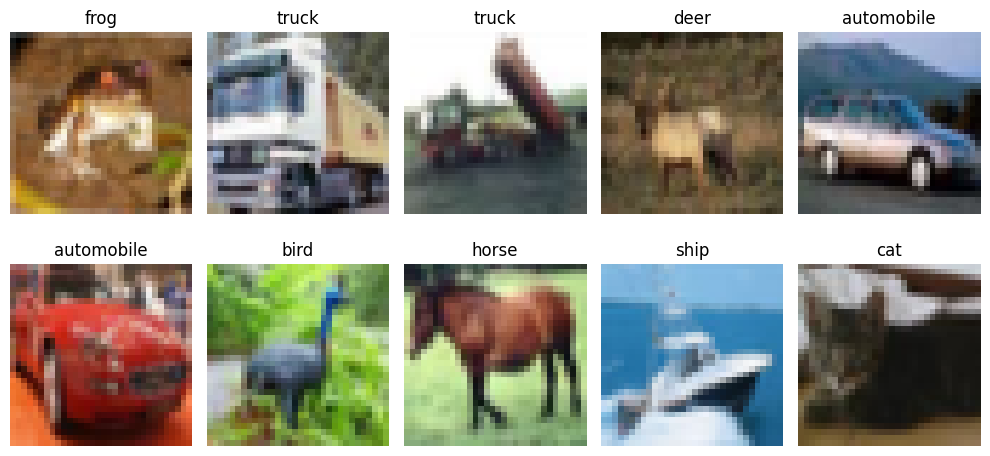

In [ ]:


# # Visualize some examples
class_names = [
  'airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog' ,
  'frog' ,
  'horse',
  'ship',
  'truck'
  ]

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


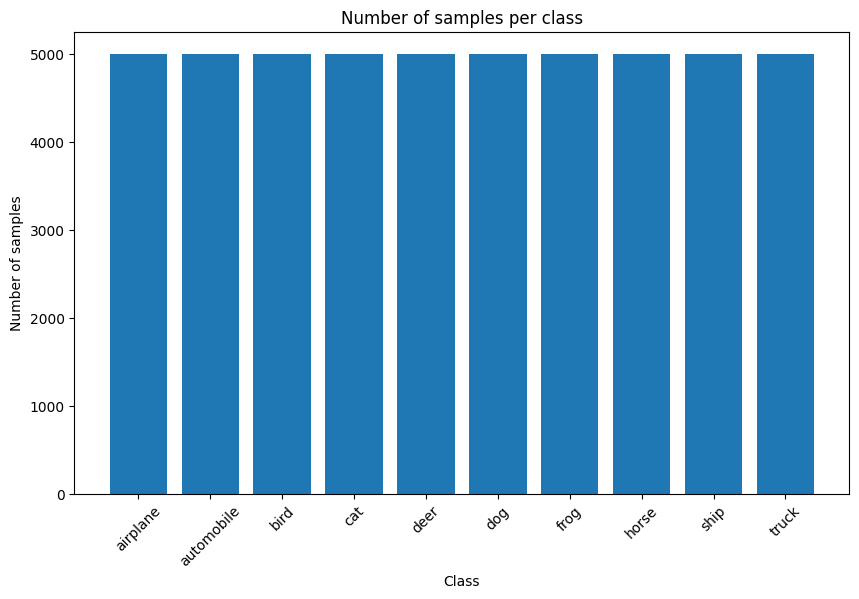

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


In [ ]:
labels = y_train.reshape(1,-1)[0]

# Count the number of samples per class
class_counts = Counter(labels)

# Sort by class index
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]


# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.xticks(rotation=45)
plt.show()

# Optional: print counts for reference
for cls, count in zip(class_names, counts):
    print(f"{cls}: {count}")

# 2. Preprocess your data Apply normalization, reshaping, label encoding, and resizing as needed.

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
# Convert labels to one-hot vectors
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Create a preprocessing layer for normalization
normalization_layer = Rescaling(1./255)
X_train = normalization_layer(X_train)
X_test = normalization_layer(X_test)

# 3. Design your CNN models

Start with a simple architecture, then experiment by increasing the number of layers, filters, and other parameters.

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

opt = Adam(learning_rate=1e-3)
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       921,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,914 (3.52 MB)

 Trainable params: 923,914 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Train your models Train at least two different CNN architectures. You can fine-tune hyperparameters such as the number of epochs (consider using early stopping), batch size, and learning rate.

In [ ]:
### Train the model
history = model.fit(X_train, y_train_cat, epochs=10, validation_split=0.2, batch_size=128)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3571 - loss: 1.7861 - val_accuracy: 0.5164 - val_loss: 1.3572
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5393 - loss: 1.2951 - val_accuracy: 0.5628 - val_loss: 1.2426
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5909 - loss: 1.1726 - val_accuracy: 0.5762 - val_loss: 1.2020
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6183 - loss: 1.0927 - val_accuracy: 0.5922 - val_loss: 1.1606
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6430 - loss: 1.0264 - val_accuracy: 0.5997 - val_loss: 1.1449
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6589 - loss: 0.9722 - val_accuracy: 0.6123 - val_loss: 1.1293
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6782 - loss: 0.9243 - val_accuracy: 0.6257 - val_loss: 1.1059
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6927 - loss: 0.8796 - val_accuracy: 

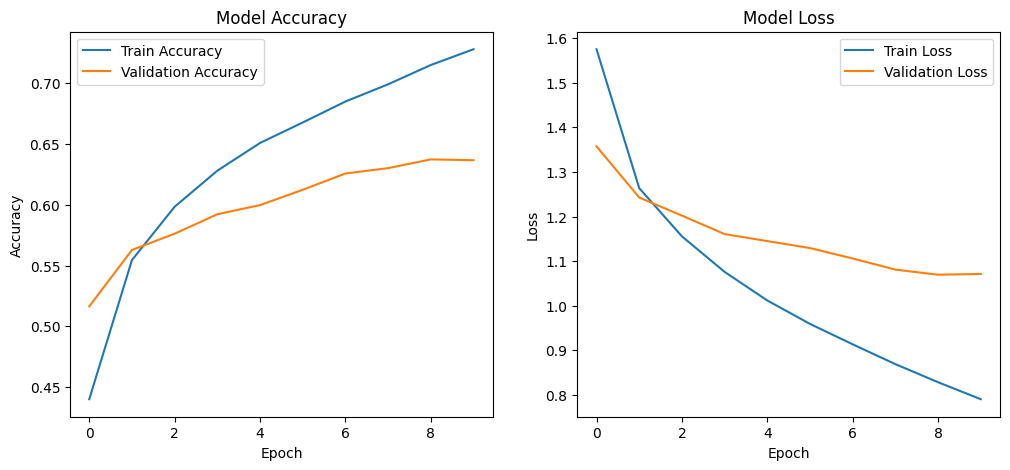

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 5. Evaluate your models
 Report metrics such as accuracy, precision, recall, and F1-score, and visualize the confusion matrix to analyze class-wise performance.

In [ ]:
# Evaluate
loss, accuracy = model.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7367 - loss: 0.7542
Train accuracy: 0.7191
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6373 - loss: 1.0521
Test accuracy: 0.6319


In [ ]:
# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.6319
Precision: 0.6340
Recall: 0.6319
F1 Score: 0.6264


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.66      0.69      0.68      1000
  automobile       0.78      0.68      0.73      1000
        bird       0.55      0.39      0.45      1000
         cat       0.48      0.45      0.46      1000
        deer       0.64      0.52      0.57      1000
         dog       0.56      0.52      0.54      1000
        frog       0.58      0.85      0.69      1000
       horse       0.73      0.69      0.71      1000
        ship       0.75      0.72      0.74      1000
       truck       0.61      0.81      0.70      1000

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.63      0.63      0.63     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


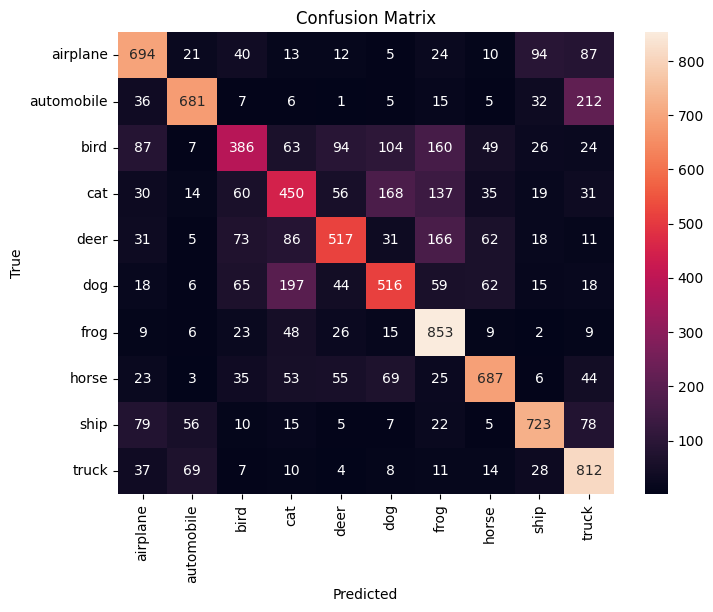

In [ ]:
# Predict & confusion matrix
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# 6. Improve the baseline
To ask:
1. How to choose the number of neurons in the dense layers after the convolution?

### Regularization:
1. Ask best practices how frequent >> hard regularization might lead to high fluctuation of perfoamnce >> the plot of train val

In [ ]:
# Define deeper CNN model
model_reg = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    ## Regularization
    BatchNormalization(),
    MaxPooling2D(2,2),
    ## Regularization
    Dropout(0.5),

    Flatten(),

    Dense(128, activation='relu'),
    ## Regularization
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_reg.summary()

opt = Adam(learning_rate=1e-3)
model_reg.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       921,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 924,042 (3.52 MB)

 Trainable params: 923,978 (3.52 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# Train on original data
history_reg = model_reg.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.3193 - loss: 2.0244 - val_accuracy: 0.3158 - val_loss: 2.0100
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4743 - loss: 1.4714 - val_accuracy: 0.5274 - val_loss: 1.4286
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5230 - loss: 1.3392 - val_accuracy: 0.5061 - val_loss: 1.3349
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5516 - loss: 1.2667 - val_accuracy: 0.5704 - val_loss: 1.1888
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5722 - loss: 1.2004 - val_accuracy: 0.5706 - val_loss: 1.1911
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5893 - loss: 1.1606 - val_accuracy: 0.5757 - val_loss: 1.1752
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5976 - loss: 1.1277 - val_accuracy: 0.5986 - val_loss: 1.1144
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6103 - loss: 1.0877 - val_accuracy:

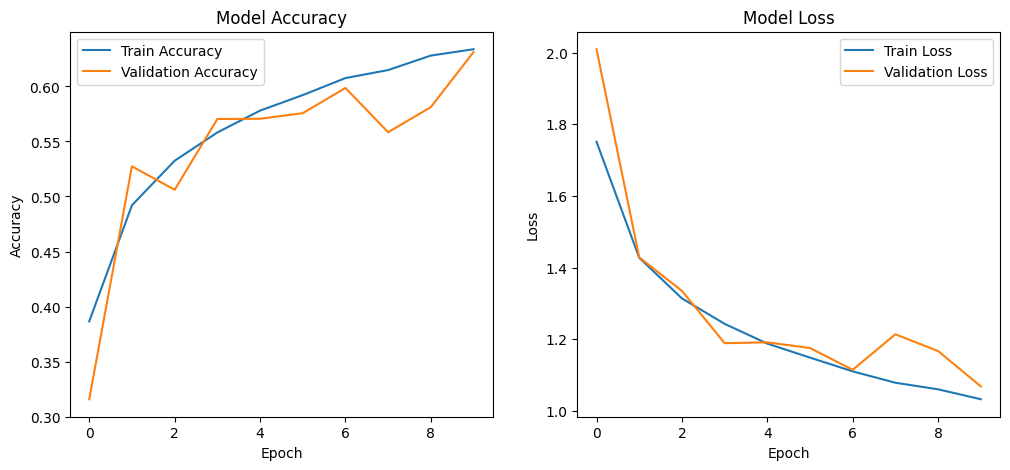

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate
loss, accuracy = model_reg.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_reg.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7436 - loss: 0.8106
Train accuracy: 0.7235
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6359 - loss: 1.0566
Test accuracy: 0.6341


### Deeper model

In [ ]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()

opt = Adam(learning_rate=1e-3)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
### Train
history_deeper = model_deeper.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.1995 - loss: 2.4121 - val_accuracy: 0.1709 - val_loss: 4.5704
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3490 - loss: 1.7533 - val_accuracy: 0.3641 - val_loss: 2.1997
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4035 - loss: 1.6255 - val_accuracy: 0.4181 - val_loss: 1.9600
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4426 - loss: 1.5384 - val_accuracy: 0.5060 - val_loss: 1.4838
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4653 - loss: 1.4787 - val_accuracy: 0.5139 - val_loss: 1.4253
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4887 - loss: 1.4224 - val_accuracy: 0.4873 - val_loss: 1.6522
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4990 - loss: 1.3818 - val_accuracy: 0.5432 - val_loss: 1.3550
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5221 - loss: 1.3365 - val_accuracy:

- Solved overfitting for 10 epochs and imporved the perfoemance

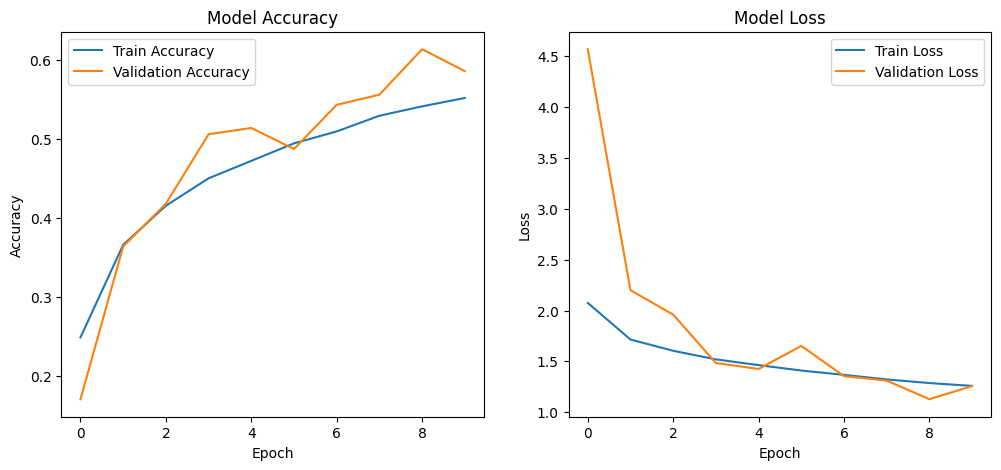

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['accuracy'], label='Train Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['loss'], label='Train Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6055 - loss: 1.1721
Train accuracy: 0.6002
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5941 - loss: 1.2432
Test accuracy: 0.5908


In [ ]:
# Predict class probabilities
y_pred_probs = model_deeper.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.5908
Precision: 0.6216
Recall: 0.5908
F1 Score: 0.5834


### Data augmentation

In [ ]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    # Max pooling layer to reduce spatial dimensions by a factor of 2
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    # Max pooling layer to reduce spatial dimensions by a factor of 2
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()

opt = Adam(learning_rate=1e-3)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [ ]:
# Use in model training
history_aug = model_deeper.fit(datagen.flow(X_train, y_train_cat, batch_size=128, shuffle=True),
          epochs=10,
          validation_data=(X_test, y_test_cat))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.2762 - loss: 1.9568 - val_accuracy: 0.4832 - val_loss: 1.4352
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.4386 - loss: 1.5529 - val_accuracy: 0.5385 - val_loss: 1.2825
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.4820 - loss: 1.4409 - val_accuracy: 0.5832 - val_loss: 1.1813
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.5110 - loss: 1.3677 - val_accuracy: 0.6065 - val_loss: 1.1033
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.5297 - loss: 1.3126 - val_accuracy: 0.6160 - val_loss: 1.0864
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.5531 - loss: 1.2601 - val_accuracy: 0.6211 - val_loss: 1.0721
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.5615 - loss: 1.2428 - val_accuracy: 0.6450 - val_loss: 1.0044
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.5699 - loss: 1.2179 - 

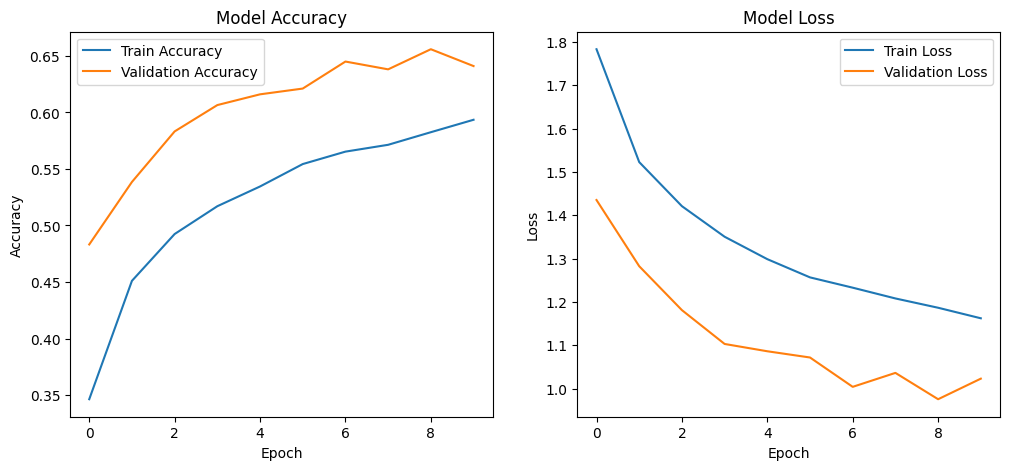

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6493 - loss: 1.0013
Train accuracy: 0.6468
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6440 - loss: 1.0145
Test accuracy: 0.6410


### Early stopping:
1. Ask about validation_data? use the test set or split another validation set >> couldnt use the val_split=0.2 val data augmenatation

2. How to intreprete when the validation metrics are better than the training? >> is it underfitting?
3. first test of early stoppying the perfoemance dropped because it stopped earlier than the previous run >> do we make the patience longer ? or change the learning rate?

In [ ]:
model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()

lr = 1e-3
opt = Adam(learning_rate=lr)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [ ]:
# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=5,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [ ]:
# Train the model with early stopping
history_early_st = model_deeper.fit(
          datagen.flow(X_train, y_train_cat, batch_size=128, shuffle=True),
          epochs=100,
          validation_data=(X_test, y_test_cat),
          callbacks=[early_stopping]
                               )

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 125ms/step - accuracy: 0.2005 - loss: 2.3777 - val_accuracy: 0.2871 - val_loss: 2.8498
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3301 - loss: 1.8086 - val_accuracy: 0.4131 - val_loss: 1.5934
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.3795 - loss: 1.6861 - val_accuracy: 0.4316 - val_loss: 1.6683
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.4103 - loss: 1.6258 - val_accuracy: 0.4921 - val_loss: 1.4168
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.4366 - loss: 1.5583 - val_accuracy: 0.5448 - val_loss: 1.3027
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.4513 - loss: 1.5202 - val_accuracy: 0.5082 - val_loss: 1.4900
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.4642 - loss: 1.4855 - val_accuracy: 0.5444 - val_loss: 1.3369
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.4786 - loss:

In [ ]:
# Evaluate the model
## higher patience
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6643 - loss: 0.9577
Train accuracy: 0.6630
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6589 - loss: 0.9770
Test accuracy: 0.6558


In [ ]:
# Evaluate the model
## with higher lr
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4548 - loss: 1.5052
Train accuracy: 0.4540
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4518 - loss: 1.4847
Test accuracy: 0.4546


In [ ]:
# Evaluate the model
## first run
loss, accuracy = model_deeper.evaluate(X_train, y_train_cat)
print(f"Train accuracy: {accuracy:.4f}")

loss, accuracy = model_deeper.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5640 - loss: 1.2287
Train accuracy: 0.5638
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5577 - loss: 1.2465
Test accuracy: 0.5603


### With Wandb

In [ ]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
lr = 1e-3
epochs = 100
batch_size = 128

model_deeper = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model_deeper.summary()


opt = Adam(learning_rate=lr)
model_deeper.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [ ]:
# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=3,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [ ]:
# Initialize wandb run
wandb.init(
    project="cifar10_dataset_FantasticFour",       # your project name
    name="EarlyStopping_1",        # run nam >> To be changed
    config={                    # hyperparameters to track
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Train with WandbCallback
model_deeper.fit(
    datagen.flow(X_train, y_train_cat, batch_size=batch_size, shuffle=True),
    epochs=epochs,
    validation_data=(X_test, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)

### Model evaluation
train_loss, train_acc = model_deeper.evaluate(datagen.flow(X_train, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_deeper.evaluate(X_test, y_test_cat, verbose=0)

# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})


# Mark run as finished
wandb.finish()

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.1948 - loss: 2.3737 - val_accuracy: 0.2731 - val_loss: 3.0344
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.3280 - loss: 1.8298 - val_accuracy: 0.4387 - val_loss: 1.5444
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.3729 - loss: 1.7030 - val_accuracy: 0.4517 - val_loss: 1.4819
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.4023 - loss: 1.6413 - val_accuracy: 0.4339 - val_loss: 1.6441
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.4350 - loss: 1.5746 - val_accuracy: 0.4055 - val_loss: 1.7380
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.4506 - loss: 1.5279 - val_accuracy: 0.4950 - val_loss: 1.5529


epoch/accuracy,▁▄▆▇▇█
epoch/epoch,▁▂▄▅▇█
epoch/learning_rate,▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▁
epoch/val_accuracy,▁▆▇▆▅█
epoch/val_loss,█▁▁▂▂▁
epoch/accuracy,0.45438
epoch/epoch,5
epoch/learning_rate,0.001
epoch/loss,1.51835
epoch/val_accuracy,0.495


# Transfer learning

Questions:
1. why is the size of the input changing the performance of the model?

### MobileNetV2

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


In [ ]:
# Convert labels to one-hot vectors
num_classes = 10 #len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

In [ ]:
# # Convert to numpy and preprocess for MobileNetV2
# X_train_scaled = preprocess_input(X_train)
# X_test_scaled = preprocess_input(X_test)

# Create a preprocessing layer for normalization
normalization_layer = Rescaling(1./255)
X_train_scaled = normalization_layer(X_train)
X_test_scaled = normalization_layer(X_test)

In [ ]:
### Resize the image to prepare for MobileNetV2: the closest to 224 the better
X_train_resized = tf.image.resize(X_train_scaled, (96, 96))
X_test_resized = tf.image.resize(X_test_scaled, (96, 96))

In [ ]:
# Build transfer learning model
base_model = MobileNetV2(input_shape=(112, 112, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

/tmp/ipython-input-2731605378.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(112, 112, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow.keras.applications import NASNetMobile

base_model = NASNetMobile(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
lr = 1e-3
epochs = 100
batch_size = 128 ## reduce to 64

# from tensorflow.keras import layers, models
model_transfer = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Pool spatial features into a vector
    Dense(128, activation='relu'), # Fully connected layer to learn new patterns
    Dense(10, activation='softmax') # Output layer with 10 classes (Fashion MNIST)
])

opt = Adam(learning_rate=lr)

In [ ]:
!pwd

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_transfer.load_weights("/content/NASNetMobile_96.keras")

model_transfer

<Sequential name=sequential_2, built=True>

In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)

y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 80ms/step
Accuracy: 0.7440
Precision: 0.7451
Recall: 0.7440
F1 Score: 0.7434


In [ ]:
class_names = [
  'airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog' ,
  'frog' ,
  'horse',
  'ship',
  'truck'
  ]

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.77      0.77      0.77      1000
  automobile       0.85      0.83      0.84      1000
        bird       0.73      0.67      0.70      1000
         cat       0.63      0.59      0.61      1000
        deer       0.67      0.69      0.68      1000
         dog       0.72      0.69      0.71      1000
        frog       0.69      0.82      0.75      1000
       horse       0.81      0.73      0.77      1000
        ship       0.80      0.84      0.82      1000
       truck       0.79      0.80      0.80      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



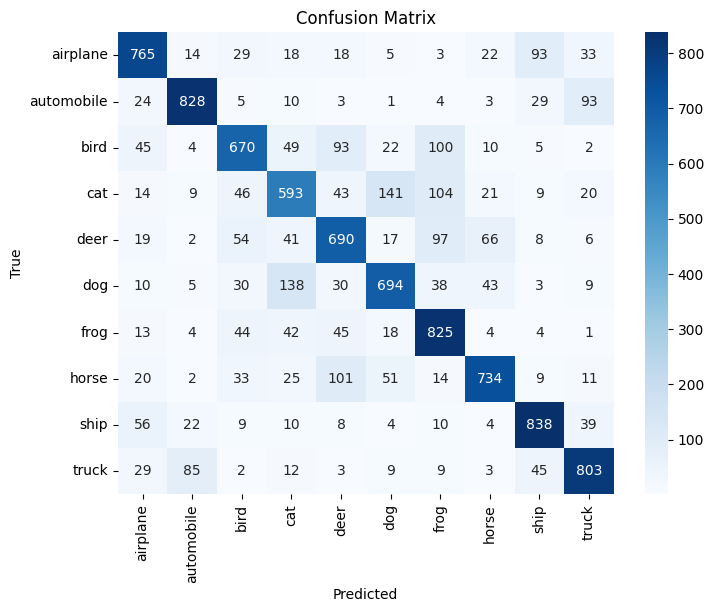

In [ ]:
# Predict & confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")        # ✅ just add this!
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

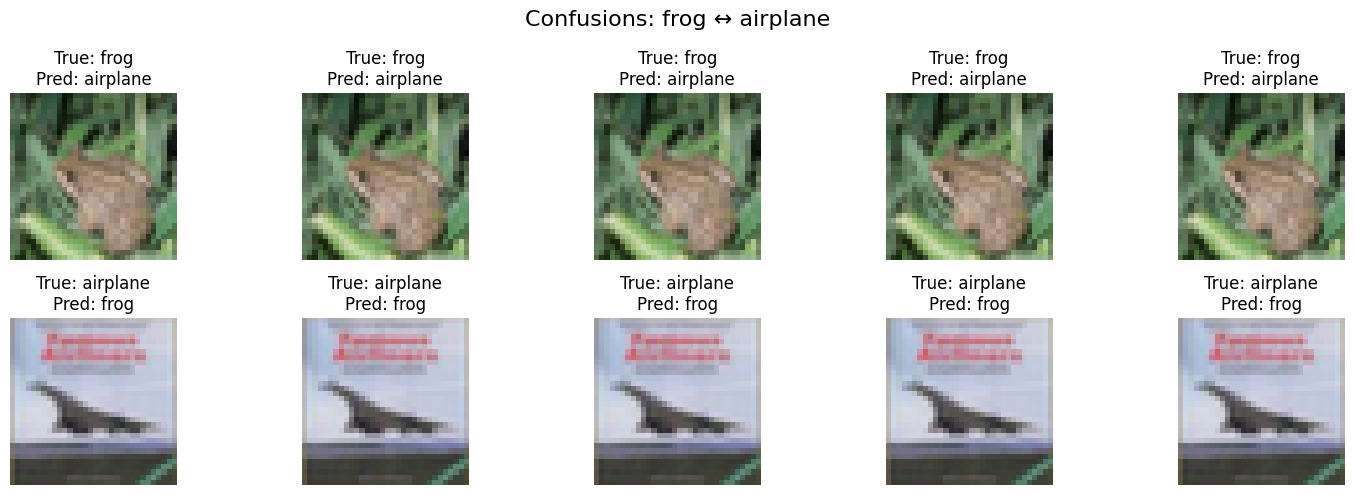

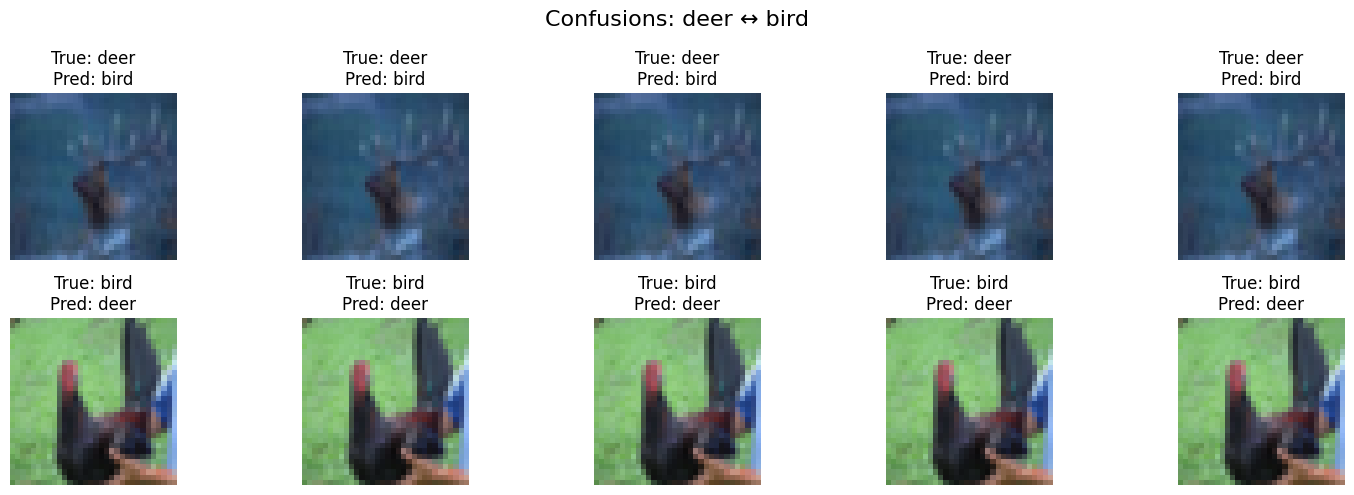

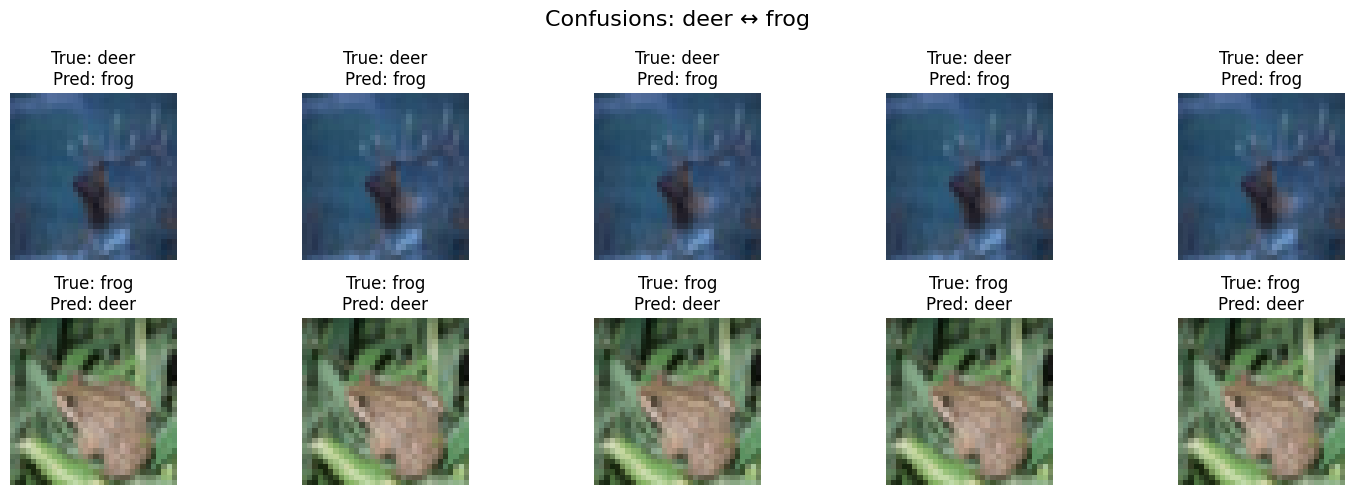

In [ ]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (6, 0),  # Shirt vs T-shirt/top
    (4, 2),  # Coat vs Pullover
    (4, 6)   # Coat vs Shirt
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):
    # Find indices of images where class1 was confused with class2 and vice versa
    idx_confused_1 = np.where((y_true == class1) & (y_pred == class2))[0]
    idx_confused_2 = np.where((y_true == class2) & (y_pred == class1))[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]])
            # plt.imshow(X_train[i], cmap='gray')
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]], cmap='gray')
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)


#### Freeze the base

In [ ]:
### Compile the model
model_transfer.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_resized) ##X_train_resized X_train

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=10,           # stop if no improvement after n epochs
    restore_best_weights=True
)


In [ ]:
### Group account
name = "MobileNetV2Model_freeze112_Norm"

wandb.init(
    entity="Ironhack_cnn_project",                  # ← your team name
    project="cifar10_dataset_FantasticFour",  # ← project gets created automatically!
    name= name,
    config={                    # hyperparameters to track
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Train with WandbCallback
model_transfer.fit(
    datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size, shuffle=True),
    epochs=epochs,
    validation_data=(X_test_resized, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)

train_loss, train_acc = model_transfer.evaluate(datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_transfer.evaluate(X_test_resized, y_test_cat, verbose=0)

# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 476ms/step - accuracy: 0.6860 - loss: 0.9359 - val_accuracy: 0.8259 - val_loss: 0.4897
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8106 - loss: 0.5512 - val_accuracy: 0.8386 - val_loss: 0.4578
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8227 - loss: 0.5095 - val_accuracy: 0.8440 - val_loss: 0.4442
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - accuracy: 0.8307 - loss: 0.4877 - val_accuracy: 0.8480 - val_loss: 0.4362
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - accuracy: 0.8380 - loss: 0.4593 - val_accuracy: 0.8469 - val_loss: 0.4296
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 346ms/step - accuracy: 0.8427 - loss: 0.4518 - val_accuracy: 0.8457 - val_loss: 0.4422
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8481 - loss: 0.4395 - val_accuracy: 0.8531 - val_loss: 0.4239
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 

In [ ]:
# ---- SAVE ----
## Store locally
### Mount the drive
from google.colab import drive
drive.mount('/content/drive')

model_transfer.save(f"{name}.keras")

In [ ]:
## Store to wandb
artifact = wandb.Artifact(name=f"{name}", type="model")
artifact.add_file(f"{name}.keras")
# artifact.add_file(f"{name}.h5")
wandb.log_artifact(artifact)


# Mark run as finished
wandb.finish()

In [ ]:
# ### Stored locally
# model_transfer.save('Mobilev2_model_freeze112.keras')
# model_transfer.save('Mobilev2_model_freeze112.h5')


In [ ]:
# # ---- LOAD later (any machine, any teammate!) ----
# import wandb
# wandb.init(entity="fantastic-four", project="cifar10_dataset_FantasticFour")

# artifact = wandb.use_artifact("fantastic-four/cifar10_dataset_FantasticFour/cifar10-model:latest")
# artifact_dir = artifact.download()    # downloads to local folder

# import tensorflow as tf
# model = tf.keras.models.load_model(f"{artifact_dir}/my_model.keras")

In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)

y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

In [ ]:
# Predict & confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")        # ✅ just add this!
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (6, 0),  # Shirt vs T-shirt/top
    (4, 2),  # Coat vs Pullover
    (4, 6)   # Coat vs Shirt
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):
    # Find indices of images where class1 was confused with class2 and vice versa
    idx_confused_1 = np.where((y_true == class1) & (y_pred == class2))[0]
    idx_confused_2 = np.where((y_true == class2) & (y_pred == class1))[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]])
            # plt.imshow(X_train[i], cmap='gray')
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]], cmap='gray')
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)


#### Unfreeze the base

In [ ]:
# !wandb login

In [ ]:
lr = 1e-3
epochs = 100
batch_size = 128

In [ ]:
# Unfreeze last layers of base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last N (e.g., last 20 layers)
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# # Freeze all layers except the last N (e.g., last 20% layers)
# fine_tune_at = int(len(base_model.layers)*0.8)
# for layer in base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# Compile model with a lower learning rate
model_transfer.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=10,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [ ]:
### Group account
name = "MobileModel_unfreeze112_earlystopping"

wandb.init(
    entity="Ironhack_cnn_project",                  # ← your team name
    project="cifar10_dataset_FantasticFour",  # ← project gets created automatically!
    name= name,
    config={                    # hyperparameters to track
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Continue training (fine-tuning)
fine_tune_epochs = 100
total_epochs = 3 + fine_tune_epochs  # if trained earlier 3 epochs

model_transfer.fit(
    datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size, shuffle=True), ##X_train_resized X_train
    epochs=total_epochs,
    initial_epoch=3,
    validation_data=(X_test_resized, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)

train_loss, train_acc = model_transfer.evaluate(datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_transfer.evaluate(X_test_resized, y_test_cat, verbose=0)

# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 4/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 470ms/step - accuracy: 0.7289 - loss: 0.7985 - val_accuracy: 0.3735 - val_loss: 5.1743
Epoch 5/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8408 - loss: 0.4651 - val_accuracy: 0.6218 - val_loss: 2.6859
Epoch 6/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8585 - loss: 0.4036 - val_accuracy: 0.6801 - val_loss: 2.2105
Epoch 7/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8757 - loss: 0.3600 - val_accuracy: 0.7695 - val_loss: 1.4553
Epoch 8/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8866 - loss: 0.3249 - val_accuracy: 0.7901 - val_loss: 1.3168
Epoch 9/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 347ms/step - accuracy: 0.8933 - loss: 0.3089 - val_accuracy: 0.7841 - val_loss: 1.1557
Epoch 10/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8997 - loss: 0.2873 - val_accuracy: 0.8112 - val_loss: 0.9270
Epoch 11/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 346ms/step - accuracy

NameError: name 'model_deeper' is not defined

Mounted at /content/drive


In [ ]:
# ---- SAVE ----
## Store locally
model_transfer.save(f"{name}.keras")

## Store to wandb
artifact = wandb.Artifact(name=f"{name}", type="model")
artifact.add_file(f"{name}.keras")
# artifact.add_file(f"{name}.h5")
wandb.log_artifact(artifact)

# Mark run as finished
wandb.finish()

epoch/accuracy,▁▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▆▇▇▇▇███████████▇████████████████
epoch/val_loss,█▄▄▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.9608
epoch/epoch,38
epoch/learning_rate,0.001
epoch/loss,0.10974
epoch/val_accuracy,0.8843


In [ ]:
# ### Mount the drive
# from google.colab import drive
# drive.mount('/content/drive')

# ### Stored locally
# model_transfer.save('Mobilev2_model_freeze112.keras')
# model_transfer.save('Mobilev2_model_freeze112.h5')

In [ ]:
# # ---- LOAD later (any machine, any teammate!) ----
# import wandb
# wandb.init(entity="Ironhack_cnn_project", project="cifar10_dataset_FantasticFour")

# artifact = wandb.use_artifact("Ironhack_cnn_project/cifar10_dataset_FantasticFour/MobileModel_unfreeze112_earlystopping:latest")
# artifact_dir = artifact.download()    # downloads to local folder

# # import tensorflow as tf
# # model = tf.keras.models.load_model(f"{artifact_dir}/my_model.keras")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


In [ ]:
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
# Convert labels to one-hot vectors
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Create a preprocessing layer for normalization
normalization_layer = Rescaling(1./255)
X_train = normalization_layer(X_train)
X_test = normalization_layer(X_test)

In [ ]:
### Resize the image to prepare for MobileNetV2: the closest to 224 the better
X_train_resized = tf.image.resize(X_train, (112, 112))
X_test_resized = tf.image.resize(X_test, (112, 112))

In [ ]:
model_transfer = tf.keras.models.load_model("/content/MobileModel_unfreeze112_earlystopping.keras")

model_transfer

<Sequential name=sequential, built=True>

In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)

y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy: 0.8916
Precision: 0.8925
Recall: 0.8916
F1 Score: 0.8914


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.89      0.92      0.90      1000
  automobile       0.97      0.93      0.95      1000
        bird       0.86      0.88      0.87      1000
         cat       0.82      0.78      0.80      1000
        deer       0.86      0.90      0.88      1000
         dog       0.85      0.82      0.83      1000
        frog       0.91      0.90      0.91      1000
       horse       0.94      0.89      0.91      1000
        ship       0.96      0.91      0.94      1000
       truck       0.88      0.98      0.92      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



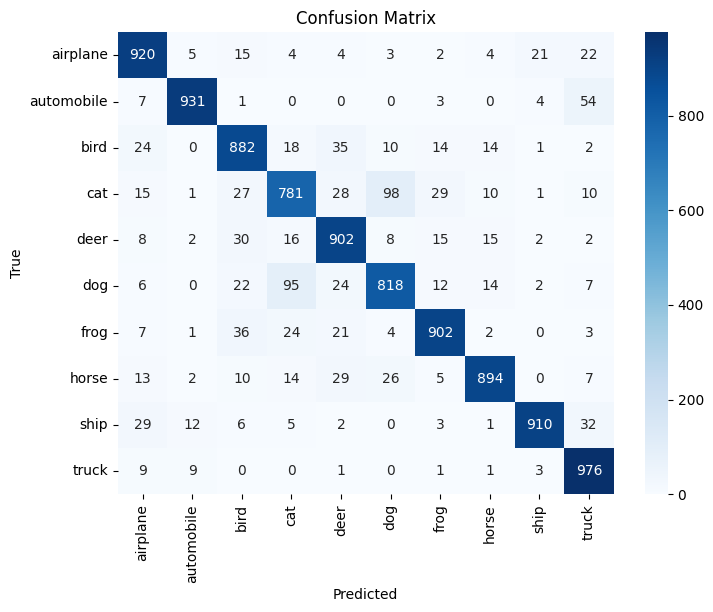

In [ ]:
# Predict & confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")        # ✅ just add this!
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

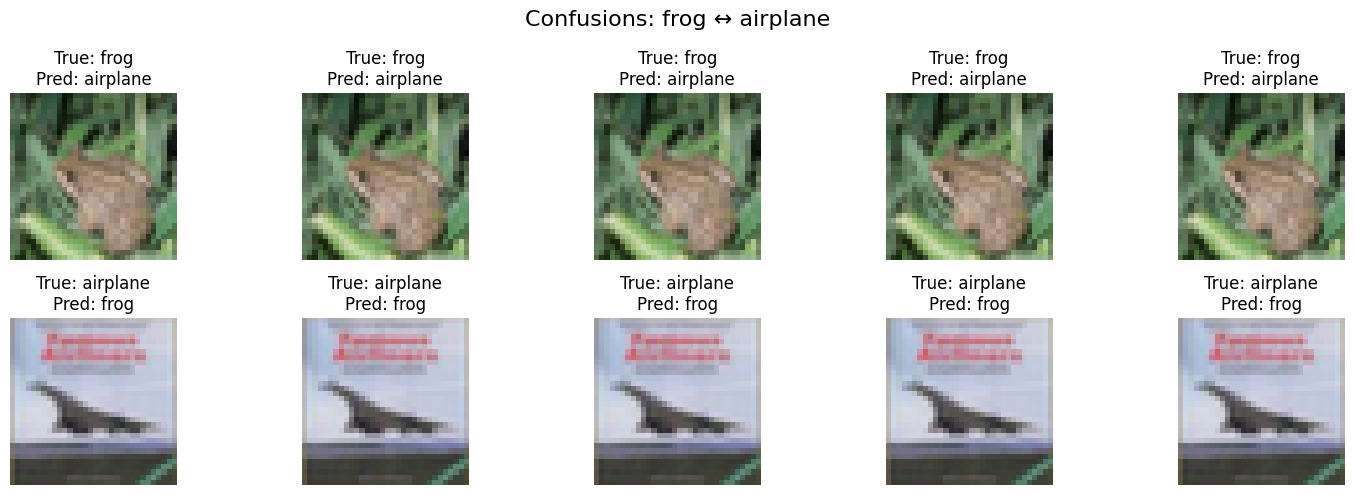

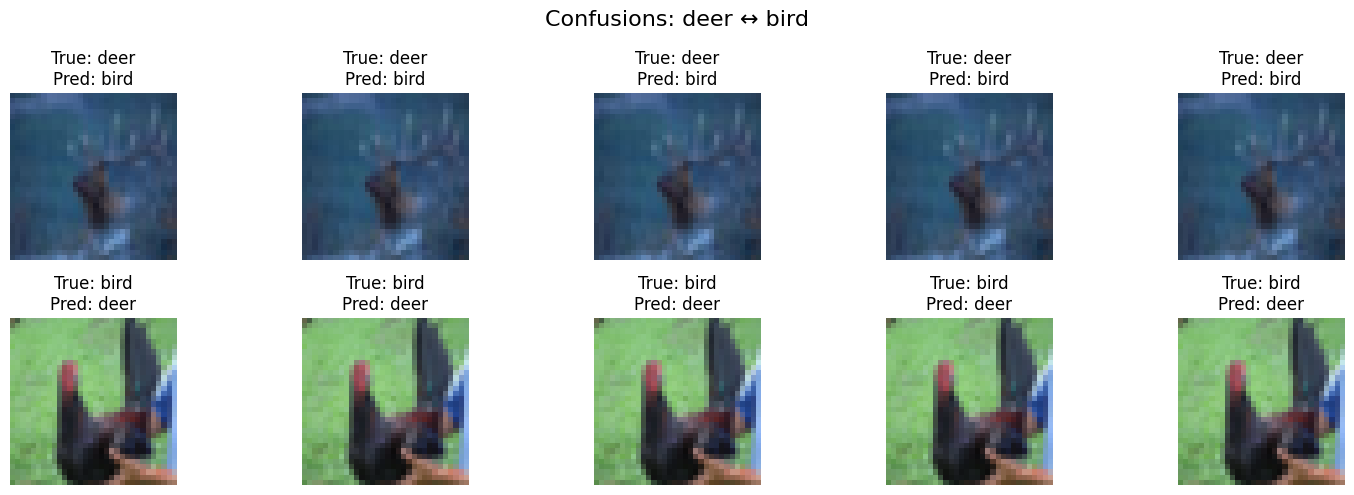

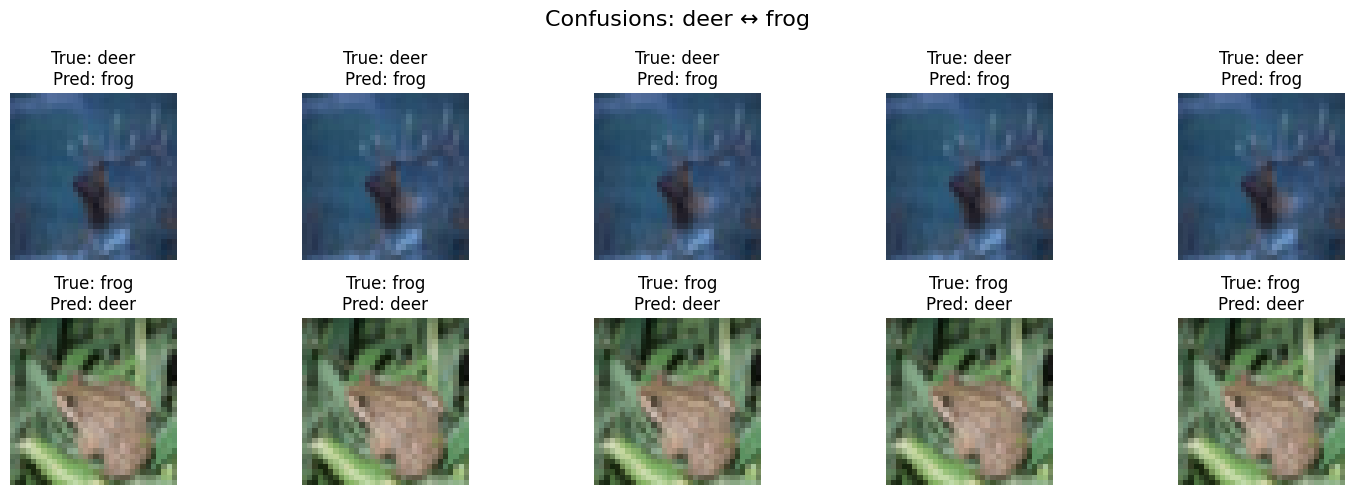

In [ ]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (6, 0),  # Shirt vs T-shirt/top
    (4, 2),  # Coat vs Pullover
    (4, 6)   # Coat vs Shirt
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):
    # Find indices of images where class1 was confused with class2 and vice versa
    idx_confused_1 = np.where((y_true == class1) & (y_pred == class2))[0]
    idx_confused_2 = np.where((y_true == class2) & (y_pred == class1))[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]])
            # plt.imshow(X_train[i], cmap='gray')
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]], cmap='gray')
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)
